<a href="https://colab.research.google.com/github/felipebatalini/AIHC5020/blob/main/homework2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Problem 1

In [2]:
def to_falsy(value):
    primitive_falsy = {
        int: 0,
        float: 0.0,
        str: '',
        bool: False,
        complex: 0j,
        type(None): None
    }

    val_type = type(value)
    if val_type in primitive_falsy:
        return primitive_falsy[val_type]
    else:
        print("non primitive type input")
        return None

# Challenge cases test
challenge_cases_p1 = [
    42, 3.14159, "Python", True, (1 + 2j), None,
    [1, 2, 3], ('a', 'b'), {'key': 'val'}
]

for val in challenge_cases_p1:
    res = to_falsy(val)
    print(f"Input: {repr(val)} -> Output: {repr(res)}")

Input: 42 -> Output: 0
Input: 3.14159 -> Output: 0.0
Input: 'Python' -> Output: ''
Input: True -> Output: False
Input: (1+2j) -> Output: 0j
Input: None -> Output: None
non primitive type input
Input: [1, 2, 3] -> Output: None
non primitive type input
Input: ('a', 'b') -> Output: None
non primitive type input
Input: {'key': 'val'} -> Output: None


Problem 2

In [3]:
def inspect_operations(arg1, arg2):
    print(type(arg1))
    print(type(arg2))

    # 3. Analyze Addition
    try:
        print(arg1 + arg2)
    except Exception:
        print("cannot add")

    # 4. Analyze Multiplication
    try:
        print(arg1 * arg2)
    except Exception:
        print("cannot multiply")

    # 5. Analyze Coercion
    try:
        type(arg2)(arg1)
        print("can coerce")
    except Exception:
        print("cannot coerce")

# Challenge cases test
challenge_cases_p2 = [
    (10.5, 2),
    ("repeat", 4),
    (True, 5),
    ([1, 2], 3),
    ("fizz", "buzz"),
    (None, "a_string"),
    ({'a': 1}, 2)
]

for case in challenge_cases_p2:
    inspect_operations(*case)
    print("-" * 20)

<class 'float'>
<class 'int'>
12.5
21.0
can coerce
--------------------
<class 'str'>
<class 'int'>
cannot add
repeatrepeatrepeatrepeat
cannot coerce
--------------------
<class 'bool'>
<class 'int'>
6
5
can coerce
--------------------
<class 'list'>
<class 'int'>
cannot add
[1, 2, 1, 2, 1, 2]
cannot coerce
--------------------
<class 'str'>
<class 'str'>
fizzbuzz
cannot multiply
can coerce
--------------------
<class 'NoneType'>
<class 'str'>
cannot add
cannot multiply
can coerce
--------------------
<class 'dict'>
<class 'int'>
cannot add
cannot multiply
cannot coerce
--------------------


Problem 3

In [4]:
def sort_and_separate_integers(data):
    if type(data) is not list:
        print("not a list")
        return None

    evens = []
    odds = []

    for i, item in enumerate(data):
        # Strict check for int, as bool is a subclass of int in Python
        if type(item) is not int:
            print(f"non-integer entry found at index {i}: {data[i]}")
            continue

        if item % 2 == 0:
            evens.append(item)
        else:
            odds.append(item)

    return (sorted(evens), sorted(odds))

# Challenge cases test
challenge_cases_p3 = [
    [5, -2, 2, 5, "skip", -3, 8],
    [],
    [10, 2, 88, 4],
    [9, 15, 1, 3],
    ['a', None, 3.14, True],
    (1, 2, 3),
    [10]
]

for case in challenge_cases_p3:
    result = sort_and_separate_integers(case)
    print(f"Result: {result}\n")

non-integer entry found at index 4: skip
Result: ([-2, 2, 8], [-3, 5, 5])

Result: ([], [])

Result: ([2, 4, 10, 88], [])

Result: ([], [1, 3, 9, 15])

non-integer entry found at index 0: a
non-integer entry found at index 1: None
non-integer entry found at index 2: 3.14
non-integer entry found at index 3: True
Result: ([], [])

not a list
Result: None

Result: ([10], [])



Problem 4

In [5]:
def analyze_list_sets(l0, l1):
    if type(l0) is not list:
        print(f"invalid input: {l0}")
        return None
    if type(l1) is not list:
        print(f"invalid input: {l1}")
        return None

    primitives = (int, float, str, bool, complex, type(None))

    valid_l0 = []
    for i, item in enumerate(l0):
        if type(item) in primitives:
            valid_l0.append(item)
        else:
            print(f"invalid entry at index {i} in l0: {l0[i]}")

    valid_l1 = []
    for i, item in enumerate(l1):
        if type(item) in primitives:
            valid_l1.append(item)
        else:
            print(f"invalid entry at index {i} in l1: {l1[i]}")

    s0 = set(valid_l0)
    s1 = set(valid_l1)

    intersection = sorted(list(s0.intersection(s1)), key=lambda x: (str(type(x)), x))
    sym_diff = sorted(list(s0.symmetric_difference(s1)), key=lambda x: (str(type(x)), x))

    return (intersection, sym_diff)

# Challenge cases test
challenge_cases_p4 = [
    ([1, 'a', 2.0], ['a', 3, 2.0]),
    ([1, 2], [1, 2, 3, 4]),
    ([1, None, {'k': 'v'}], [1, 2, None]),
    ([1, 2, 3], [4, 5, 6]),
    ([], [1, 2, 3]),
    ("not a list", [1, 2]),
    ([1, 2], [1, 2])
]

for case in challenge_cases_p4:
    res = analyze_list_sets(*case) if isinstance(case, tuple) else analyze_list_sets(case, [1, 2])
    print(f"Result: {res}\n")

Result: ([2.0, 'a'], [1, 3])

Result: ([1, 2], [3, 4])

invalid entry at index 2 in l0: {'k': 'v'}
Result: ([None, 1], [2])

Result: ([], [1, 2, 3, 4, 5, 6])

Result: ([], [1, 2, 3])

invalid input: not a list
Result: None

Result: ([1, 2], [])



Problem 5

In [6]:
def summarize_numpy_array(arr):
    if not isinstance(arr, np.ndarray) or arr.ndim != 1 or not np.issubdtype(arr.dtype, np.floating):
        print("invalid input")
        return None

    if arr.size == 0:
        return {
            'min': None, 'mean': None, 'max': None, 'std_dev': None,
            'p25': None, 'p50': None, 'p75': None, 'iqr': None
        }

    p25 = float(np.percentile(arr, 25))
    p75 = float(np.percentile(arr, 75))

    return {
        'min': float(np.min(arr)),
        'mean': float(np.mean(arr)),
        'max': float(np.max(arr)),
        'std_dev': float(np.std(arr)),
        'p25': p25,
        'p50': float(np.percentile(arr, 50)),
        'p75': p75,
        'iqr': p75 - p25
    }

# Challenge cases test
challenge_cases_p5 = [
    np.array([10.5, 2.3, -5.7, 8.1, 0.0, 3.9]),
    np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]),
    np.array([], dtype=np.float64),
    [1.0, 2.0, 3.0],
    np.array([[1.0, 2.0], [3.0, 4.0]]),
    np.arange(5)
]

for case in challenge_cases_p5:
    res = summarize_numpy_array(case)
    print(f"Result: {res}\n")

Result: {'min': -5.7, 'mean': 3.183333333333333, 'max': 10.5, 'std_dev': 5.2922637458421855, 'p25': 0.575, 'p50': 3.0999999999999996, 'p75': 7.05, 'iqr': 6.475}

Result: {'min': 1.0, 'mean': 4.5, 'max': 8.0, 'std_dev': 2.29128784747792, 'p25': 2.75, 'p50': 4.5, 'p75': 6.25, 'iqr': 3.5}

Result: {'min': None, 'mean': None, 'max': None, 'std_dev': None, 'p25': None, 'p50': None, 'p75': None, 'iqr': None}

invalid input
Result: None

invalid input
Result: None

invalid input
Result: None



Problem 6

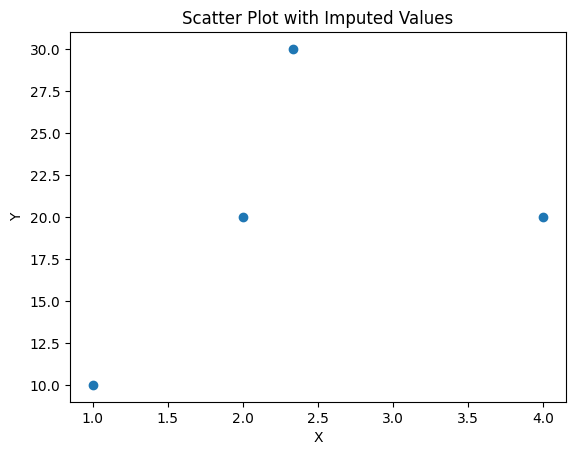

In [7]:
def create_scatter_plot(x_arr, y_arr):
    valid_x = isinstance(x_arr, np.ndarray) and x_arr.ndim == 1 and np.issubdtype(x_arr.dtype, np.floating)
    valid_y = isinstance(y_arr, np.ndarray) and y_arr.ndim == 1 and np.issubdtype(y_arr.dtype, np.floating)

    if not (valid_x and valid_y):
        print("invalid input")
        return

    if len(x_arr) != len(y_arr):
        print("arrays are not the same size.")
        return

    mx = np.ma.masked_invalid(x_arr)
    x_filled = mx.filled(mx.mean())

    my = np.ma.masked_invalid(y_arr)
    y_filled = my.filled(my.mean())

    plt.figure()
    plt.scatter(x_filled, y_filled)
    plt.title("Scatter Plot with Imputed Values")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.show()

# Base Case test
x = np.array([1.0, 2.0, np.nan, 4.0])
y = np.array([10.0, 20.0, 30.0, np.nan])
create_scatter_plot(x, y)

Problem 7

In [8]:
import numpy as np

def solve_linear_system(A, b):
    # Check if inputs are numpy arrays
    if not isinstance(A, np.ndarray) or not isinstance(b, np.ndarray):
        print("invalid input")
        return None

    # Check dimensions: A must be 2D square (N, N), b must be 1D (N,)
    if A.ndim != 2 or A.shape[0] != A.shape[1] or b.ndim != 1 or A.shape[0] != len(b):
        print("invalid input")
        return None

    # Check dtype is float
    if not np.issubdtype(A.dtype, np.floating) or not np.issubdtype(b.dtype, np.floating):
        print("invalid input")
        return None

    # Check determinant to see if matrix is singular / invertible
    det = np.linalg.det(A)
    if np.isclose(det, 0):
        print("matrix is singular")
        return None

    # Solve system Ax = b
    return np.linalg.solve(A, b)

# Challenge cases test
challenge_cases_p7 = [
    (np.array([[2.0, 1.0], [1.0, 3.0]]), np.array([8.0, 14.0])),  # Standard 2x2
    (np.array([[1.0, 2.0], [2.0, 4.0]]), np.array([5.0, 10.0])),  # Singular
    (np.array([[1, 2], [3, 4]]), np.array([5, 6])),              # Int dtype (invalid)
    (np.array([[1.0, 2.0]]), np.array([3.0, 4.0])),               # Non-square A
]

for A_test, b_test in challenge_cases_p7:
    sol = solve_linear_system(A_test, b_test)
    print(f"Solution:\n{sol}\n" + "-"*20)

Solution:
[2. 4.]
--------------------
matrix is singular
Solution:
None
--------------------
invalid input
Solution:
None
--------------------
invalid input
Solution:
None
--------------------


Problem 8

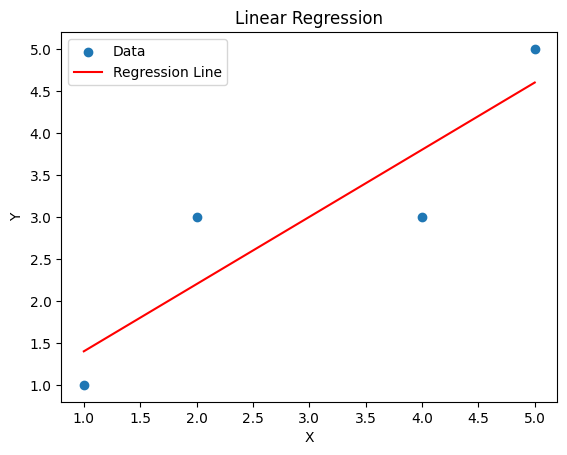

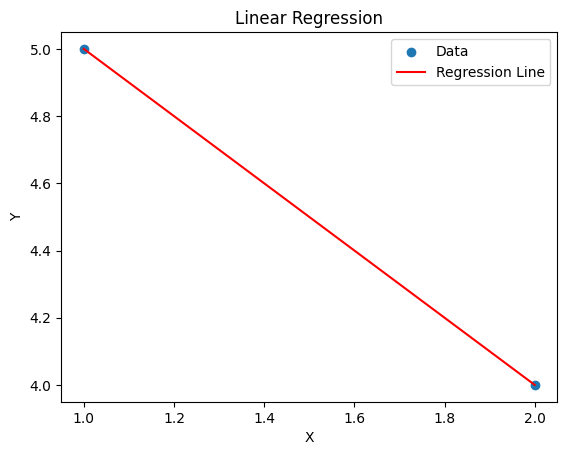

invalid input
horizontal line detected
vertical line detected


In [9]:
import numpy as np
import matplotlib.pyplot as plt

def plot_regression(x_arr, y_arr):
    # 1. Validation: numpy array, 1D, float dtype
    valid_x = isinstance(x_arr, np.ndarray) and x_arr.ndim == 1 and np.issubdtype(x_arr.dtype, np.floating)
    valid_y = isinstance(y_arr, np.ndarray) and y_arr.ndim == 1 and np.issubdtype(y_arr.dtype, np.floating)

    if not (valid_x and valid_y):
        print("invalid input")
        return None

    if len(x_arr) != len(y_arr):
        print("invalid input")
        return None

    # Remove NaN values pairwise
    valid_mask = ~np.isnan(x_arr) & ~np.isnan(y_arr)
    x_clean = x_arr[valid_mask]
    y_clean = y_arr[valid_mask]

    # Need at least 2 points to fit a line
    if len(x_clean) < 2:
        print("invalid input")
        return None

    # Check for horizontal line (zero variance in y)
    if np.all(y_clean == y_clean[0]):
        print("horizontal line detected")
        return None

    # Check for vertical line (zero variance in x)
    if np.all(x_clean == x_clean[0]):
        print("vertical line detected")
        return None

    # Compute linear regression slope and intercept
    slope, intercept = np.polyfit(x_clean, y_clean, 1)

    # Plot
    plt.figure()
    plt.scatter(x_clean, y_clean, label='Data')

    x_line = np.linspace(x_clean.min(), x_clean.max(), 100)
    plt.plot(x_line, slope * x_line + intercept, color='red', label='Regression Line')

    plt.title("Linear Regression")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    plt.show()

# Challenge cases test
challenge_cases_p8 = [
    (np.array([1.0, 2.0, 4.0, 5.0]), np.array([1.0, 3.0, 3.0, 5.0])), # Standard case
    (np.array([1.0, 2.0, 3.0, np.nan]), np.array([5.0, 4.0, np.nan, 2.0])), # NaNs
    (np.array([1.0, 2.0]), np.array([1.0, 2.0, 3.0])), # Mismatched lengths
    (np.arange(4, dtype=float), np.array([5.0, 5.0, 5.0, 5.0])), # Horizontal line
    (np.array([5.0, 5.0, 5.0, 5.0]), np.arange(4, dtype=float))  # Vertical line
]

for x_test, y_test in challenge_cases_p8:
    plot_regression(x_test, y_test)